## Importación de librerías

In [3]:
# Data processing  
# -----------------------------------------------------------------------
import pandas as pd
import numpy as np

#Exploración de archivos
# -----------------------------------------------------------------------
import sys
sys.path.append('../')

# Visualization  
# -----------------------------------------------------------------------
import seaborn as sns
import matplotlib.pyplot as plt

# Model selection and evaluation  
# -----------------------------------------------------------------------
from sklearn.model_selection import train_test_split

# Regression models  
# -----------------------------------------------------------------------
from sklearn.linear_model import LinearRegression

# Metrics  
# -----------------------------------------------------------------------
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

## Carga de datos

In [4]:
df = pd.read_csv('../data/df_regresion.csv', index_col=0)
df.head()

,horas_estudio_semanal,nota_anterior,tasa_asistencia,horas_sueno,edad,nivel_dificultad,horario_estudio_preferido,estilo_aprendizaje,nota_final,aprobado,tiene_tutor_No,tiene_tutor_Sí
0,0.331561,0.269009,0.833002,0.445949,0.636364,0.0,0.577230,1.000000,84.4,1.0,0.0,1.0
1,0.418439,0.726082,0.793121,0.102807,0.000000,1.0,0.577230,0.000000,72.0,1.0,1.0,0.0
2,0.146282,0.862624,0.682795,0.625874,0.636364,0.0,0.505606,1.000000,80.0,1.0,1.0,0.0
3,0.235301,0.741118,0.785623,0.765471,0.454545,0.0,1.000000,0.449354,78.2,1.0,1.0,0.0
4,0.000000,0.517917,0.431749,0.445307,0.272727,0.5,1.000000,0.792851,66.0,1.0,1.0,0.0


## Separación del conjunto de datos

In [5]:
# Se elimina la columna aprobado por ser una variable dependiente de la nota final que no aporta información adicional y puede introducir ruido.
df.drop(columns=['aprobado'], inplace=True)

In [6]:
# Variable objetivo
tv = 'nota_final'

# Se definen las variables predictoras (X) y la variable objetivo (y)
X = df.drop(columns=[tv])  # Características
y = df[tv]  # Etiqueta o resultado

In [7]:
# Se dividen los datos en 80% entrenamiento y 20% prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Se muestran los tamaños de los conjuntos resultantes
print(f"Tamaño del conjunto de entrenamiento: {X_train.shape}")
print(f"Tamaño del conjunto de prueba: {X_test.shape}")

Tamaño del conjunto de entrenamiento: (800, 10)
Tamaño del conjunto de prueba: (200, 10)


## Entrenamiento del modelo

In [8]:
# Se crea el modelo de regresión lineal
modelo = LinearRegression()

In [9]:
# Se ajusta el modelo con los datos de entrenamiento
modelo.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [10]:
# Se hacen predicciones con los datos de prueba
y_pred = modelo.predict(X_test)

## Validación del modelo

### Comparación con scatterplot

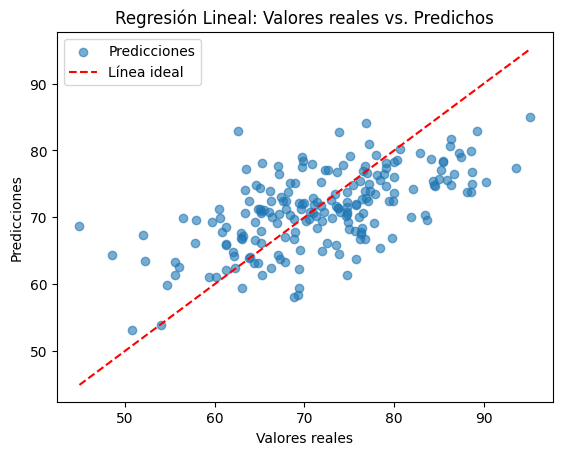

In [11]:
# Se grafican valores reales vs. predichos
plt.scatter(y_test, y_pred, label="Predicciones", alpha=0.6)

# Se agrega línea de referencia (y = x)
min_val = min(y_test.min(), y_pred.min())  # Valor mínimo entre reales y predichos
max_val = max(y_test.max(), y_pred.max())  # Valor máximo entre reales y predichos
plt.plot([min_val, max_val], [min_val, max_val], color="red", linestyle="--", label="Línea ideal")

plt.xlabel("Valores reales")
plt.ylabel("Predicciones")
plt.title("Regresión Lineal: Valores reales vs. Predichos")
plt.legend()
plt.show()

### Comparación de distribuciones

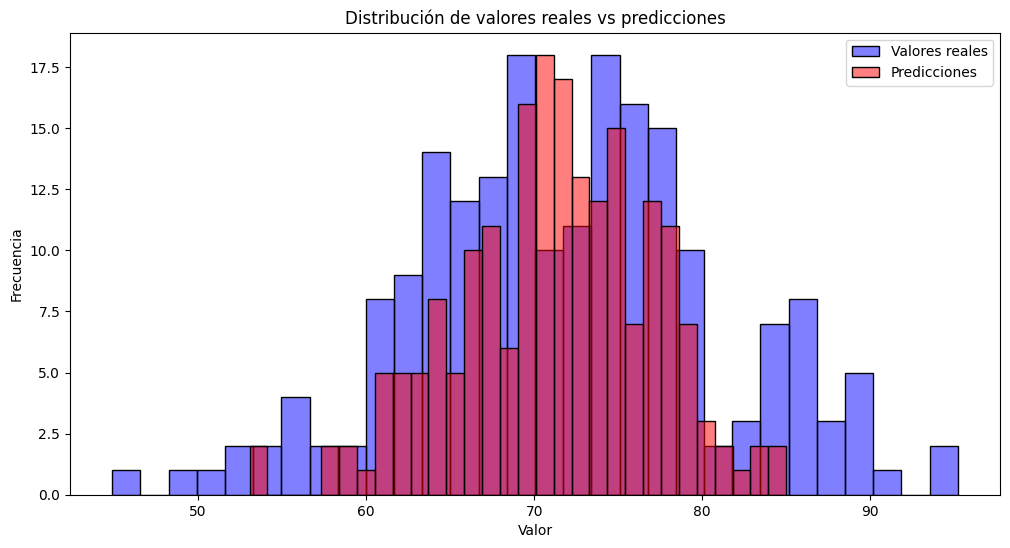

In [12]:
# Se grafican valores reales vs. predichos
plt.figure(figsize=(12, 6))

n_bins = 30

# Histograma de y_test (azul)
sns.histplot(y_test, bins=n_bins, edgecolor='black', color='blue', alpha=0.5, label='Valores reales')

# Histograma de y_pred (rojo)
sns.histplot(y_pred, bins=n_bins, edgecolor='black', color='red', alpha=0.5, label='Predicciones')

plt.xlabel('Valor')
plt.ylabel('Frecuencia')
plt.title('Distribución de valores reales vs predicciones')
plt.legend()
plt.show()

## Residuos

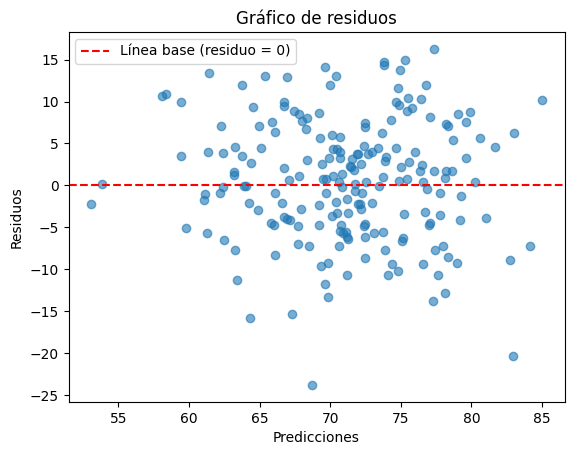

In [13]:
# Se calcula los residuos
residuos = y_test - y_pred

# Se grafican residuos
plt.scatter(y_pred, residuos, alpha=0.6)
plt.axhline(y=0, color="red", linestyle="--", label="Línea base (residuo = 0)")

# Etiquetas y título
plt.xlabel("Predicciones")
plt.ylabel("Residuos")
plt.title("Gráfico de residuos")
plt.legend()
plt.show()

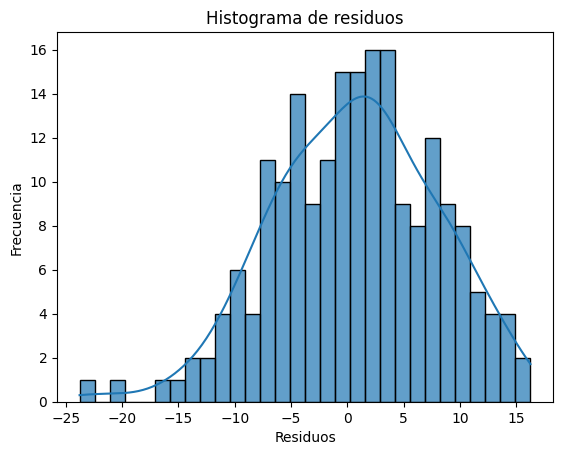

In [14]:
# Se grafican histograma de los residuos
sns.histplot(residuos, bins=30, kde=True, edgecolor="black", alpha=0.7)

# Etiquetas y título
plt.xlabel("Residuos")
plt.ylabel("Frecuencia")
plt.title("Histograma de residuos")

# Se muestra gráfico
plt.show()

## Importancia de características

In [15]:
# Se crea dataFrame con los coeficientes
coef_df = pd.DataFrame({'Feature': X.columns.to_list(), 'Coefficient': modelo.coef_})
coef_df = coef_df.sort_values(by='Coefficient', key=abs)  # Ordenar por magnitud

In [16]:
coef_df.sort_values(by='Coefficient', ascending=False, key=abs)

,Feature,Coefficient
0,horas_estudio_semanal,16.935539
1,nota_anterior,11.671476
2,tasa_asistencia,7.308598
5,nivel_dificultad,-3.068525
7,estilo_aprendizaje,1.746066
6,horario_estudio_preferido,0.761168
4,edad,0.427124
3,horas_sueno,-0.350702
8,tiene_tutor_No,-0.322717
9,tiene_tutor_Sí,0.322717


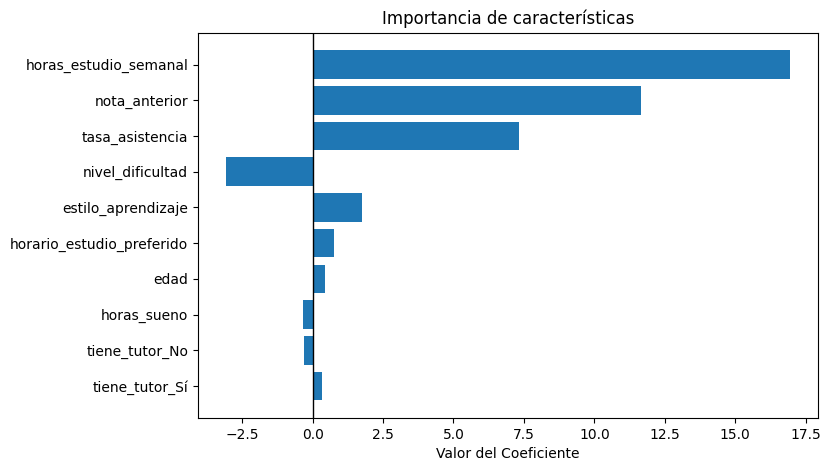

In [17]:
# Visualización los coeficientes en un gráfico de barras
plt.figure(figsize=(8, 5))
plt.barh(coef_df['Feature'], coef_df['Coefficient'])
plt.xlabel("Valor del Coeficiente")
plt.title("Importancia de características")
plt.axvline(0, color='black', linewidth=1)  # Línea en el 0 para referencia
plt.show()

## Métricas

In [18]:
# Predicciones
y_train_pred = modelo.predict(X_train)
y_test_pred = modelo.predict(X_test)

In [19]:
# Cálculo de métricas
metrics = {
    "train": {
        "R2": r2_score(y_train, y_train_pred),
        "MAE": mean_absolute_error(y_train, y_train_pred),
        "RMSE": np.sqrt(mean_squared_error(y_train, y_train_pred)),
    },
    "test": {
        "R2": r2_score(y_test, y_test_pred),
        "MAE": mean_absolute_error(y_test, y_test_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_test_pred)),
    },
}

# Se muestran métricas en un dataFrame
df_metrics = pd.DataFrame(metrics).T

In [20]:
y.median()

np.float64(71.4)

In [21]:
df_metrics.round(2)

,R2,MAE,RMSE
train,0.39,6.02,7.57
test,0.36,5.81,7.22


### Entrenamiento final

In [ ]:
import joblib

# Se entrena el modelo con todo el conjunto de datos
model_final = LinearRegression()
model_final.fit(X, y)

# Se guarda el modelo entrenado para producción
joblib.dump(model_final, "../modelos/modelo_regresion.pkl")

['../modelos/modelo_regresion.pkl']

### Optimización

In [ ]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet

# Se definen modelos con regularización
models = {
    "Linear": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.1),
    "ElasticNet": ElasticNet(alpha=0.1, l1_ratio=0.5),
}

# Se inicializa diccionario para métricas
metrics_results = {}

# Se entrena y se evalua cada modelo
for name, model in models.items():
    model.fit(X_train, y_train)  # Entrenar el modelo

    # Se predice en entrenamiento y prueba
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Se calculan métricas
    metrics_results[name] = {
        "Train R²": r2_score(y_train, y_train_pred),
        "Train MAE": mean_absolute_error(y_train, y_train_pred),
        "Train RMSE": np.sqrt(mean_squared_error(y_train, y_train_pred)),
        "Test R²": r2_score(y_test, y_test_pred),
        "Test MAE": mean_absolute_error(y_test, y_test_pred),
        "Test RMSE": np.sqrt(mean_squared_error(y_test, y_test_pred)),
    }

# Se convierten métricas a dataFrame
df_metrics = pd.DataFrame(metrics_results).T


In [24]:
df_metrics.round(2)

,Train R²,Train MAE,Train RMSE,Test R²,Test MAE,Test RMSE
Linear,0.39,6.02,7.57,0.36,5.81,7.22
Ridge,0.39,6.03,7.57,0.36,5.81,7.21
Lasso,0.38,6.06,7.62,0.37,5.83,7.18
ElasticNet,0.32,6.42,7.99,0.32,6.01,7.45
